# The temporal coherence fit 

Once the exponential fit has been generated, I can plot it in a couple different ways.  

In [1]:
# import libraries
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxa
import math
from rasterio.enums import Resampling
from rasterio.transform import rowcol
import rasterio
from datetime import datetime 

from pathlib import Path
from datetime import datetime
from time import time
import tifffile as tif

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)
from taus import decorrelation_temporal_model

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
BASE_DATADIR = '/bsuhome/julialober/scratch/comp_transfer/snowex_uavsar_coherence/data/snowex_lowman/'
plt.style.use('seaborn-v0_8')

In [5]:
# load the file with taus 
tau_file = BASE_DATADIR + 'taus/lowman_05208_tau_fixed_gamma.tif'

print(f"Loading {tau_file}... as `taus`")
taus = rxa.open_rasterio(tau_file)

Loading /bsuhome/julialober/scratch/comp_transfer/snowex_uavsar_coherence/data/snowex_lowman/taus/lowman_05208_tau_fixed_gamma.tif... as `taus`


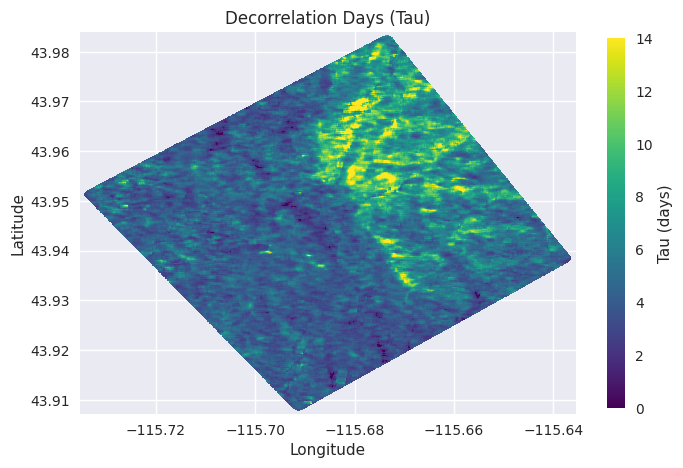

In [11]:
# plot taus 

fig, ax = plt.subplots(figsize=(8, 6))
taus_plot = taus.plot(ax=ax, cmap='viridis', vmin=0, vmax=14, add_colorbar=False)
# add points to map
# ax.plot(pilot_n[1], pilot_n[0], markersize=7, marker=pilot_n_marker, color=pilot_n_color, linestyle='None', label='High Tau')
# ax.plot(pilot_s[1], pilot_s[0], markersize=7, marker=pilot_s_marker, color=pilot_s_color, linestyle='None', label='Low Tau')
# ax.plot(mcs_snotel[1], mcs_snotel[0], markersize=8, marker=mcs_snotel_marker, color=mcs_snotel_color, linestyle='None', label='MCS SNOTEL')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
# ax.legend(loc='lower right')
cbar = fig.colorbar(taus_plot, ax=ax, orientation='vertical', label='Tau (days)', shrink=0.8)
plt.title('Decorrelation Days (Tau)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# save figure
# fig.savefig(fig_dir + 'mores_creek_taus.png', dpi=300, bbox_inches='tight')

In [ ]:
# calculate 12 day coherence 
